> This script is deigned to be used with conda env
> crime_weather_env

ETL pipeline at [combine_crime_ceda_data.py](../1_ETL/combine_crime_ceda_data.py).  
Cluser labels generated at [spatial_clustering.ipynb](../2_spatial_clusters/spatial_clustering.ipynb).  
Context labels applied at [context_lables.ipynb](../3_context_lables/context_lables.ipynb)


# Logistic Regression

This script applies logistic regression on the 'Leisure' and 'Retail' cluster datasets to test the project hypotheses.

These are:

 - **HO, Null hypothesis**:   
    "The maximum ambient temperature (tasmax) and relative humidity (hurs) have no statistically significant effect on the odds of a crime occuring in a Leiure cluster versus a Retail cluster. Spatial distrubtions of crime occurence across land use contexts is independent of weather variables."  
      
 - **H1, Alternative hypothesis**:  
    "Increases in maximum ambient air temperature and humidity significantly increase the odds of a crime occuring in a Leisure cluster versus a retail cluster."   

Background Reading:  
[Statsmodels Logit](https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html#statsmodels.discrete.discrete_model.Logit)  
[A.L Nelson, R.D.F Bromley & C.J Thomas (2000)](https://doi.org/10.1016/S0143-6228(01)00008-X)  
[Brunsdon, C., Corcoran, J., Higgs, G. & Ware, A. (2009).](https://doi.org/10.1068/b32133)  
[Narushige Shiode, Shino Shiode, Hayato Nishi & Kimihiro Hino (2023)](https://doi.org/10.1007/s43762-023-00094-x)  
[Supression effect paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC2819361/pdf/nihms-173346.pdf)  
 
Note that since this is looking at inference of 'does weather imapact crime event occurance is leisure/retail zones'  and not 'can we predict if crime will occur in a leisure or retail zone' this analysis is **not building a predictive model**. If we were then the predictors would need to be standardised, trained and then tested on the data to get the best possible fit for future predictions. Because we are not doing that (ethics and oversimplification of crime drivers) those steps are not needed here. 

## Import modules

In [42]:
# standard libraries
import os
from pathlib import Path

# other libraries
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

# typers and submodules
from duckdb import DuckDBPyConnection
from pandas import DataFrame


## Directories, db and Path Setup

In [2]:
cwd: str = os.getcwd()
data_dir: Path = Path(cwd).parent / 'data' / 'police_archives'
crime_db: Path = data_dir/'crime_archive.db'

Connect to the duckdb

In [3]:
con: DuckDBPyConnection = duckdb.connect(database=crime_db)

Introspect

In [4]:
# introspect
con.execute(query="SHOW TABLES").fetchall()

[('crimetology_NS',),
 ('crimetology_NS_clean',),
 ('crimetology_coords_lookup',),
 ('street_data',)]

In [5]:
con.execute(query="SELECT * FROM crimetology_NS_clean LIMIT 2;").df()


,Crime ID,Month,Longitude,Latitude,Crime type,tasmax,tas,groundfrost,sun,snowLying,tasmin,rainfall,hurs,sfcWind,Cluster ID,Crime Bucket,Cluster Label
0,00926dfc98a1ad484fec277ced4f0237c1032d9d63f4f0...,2020-01,0.521596,52.345789,Violence and sexual offences,9.597225,6.834480,8.521248,57.155247,0.028889,4.043394,46.032112,88.652786,4.317238,869,OTHER,Other
1,08088ddb322e7dfb2bc9eb9736776849fa6e6568e28725...,2020-01,1.188665,52.041702,Violence and sexual offences,9.253441,6.699946,12.421773,53.776817,0.017040,4.145340,42.233070,88.948593,4.330167,5065,OTHER,Other


# Extract features

Need to keep in-memory data footprint reasonable

In [6]:
feature_query = """SELECT "Crime ID",
                          "Cluster Label",
                          "tasmax",                                        --Independent variable 1
                          "hurs"                                           --Independent varibale 2
                          FROM crimetology_NS_clean 
                          WHERE "Cluster Label" IN ('Leisure','Retail');   --Dependent variable
                """


In [7]:
features_df: DataFrame = con.execute(query=feature_query).df()
features_df

,Crime ID,Cluster Label,tasmax,hurs
0,42a431be7080b174dc6a6fe419678ae1c6e2a81afc82d6...,Leisure,8.992604,89.899658
1,f92c6b203564a084e8ec1ae523433302ca903f9783c89f...,Retail,9.033701,88.757492
2,728733ef4da4abf89f8a83b3f1104d1142683febcfefc7...,Leisure,9.201315,88.917358
3,f183e986bb0043037d40b5848c7d66bacd570eecf7a9c4...,Retail,9.237802,89.107567
4,08059176f2ca15ed52158c38966df742603f12105e5942...,Retail,9.297161,89.673691
...,...,...,...,...
43929,72c74647c90095c29306baba145140affcb7aaa00ca953...,Leisure,21.899710,78.565903
43930,b01fe8dc3c05f6436741f4e67f68cb19426db26763ae01...,Retail,21.902161,79.977829
43931,7d4a1dca0d15ac78d98770d23d604c0391df74e2f2e2a2...,Retail,21.902161,79.977829
43932,efe28a09d0b076e396b4e775ca9ccf78b0ee73c3095d64...,Retail,21.902161,79.977829


This yields 43934 rows of data for the logistic regression. 

Next Step: encode the binary value associated with each cluster label. 

|Binary Value|Zone|
| :---: | :---:| 
|1 | Leisure | 
|0 | Retail |

In [8]:
features_df["Binary Value"] = (features_df["Cluster Label"]=='Leisure').astype(int)

In [9]:
features_df

,Crime ID,Cluster Label,tasmax,hurs,Binary Value
0,42a431be7080b174dc6a6fe419678ae1c6e2a81afc82d6...,Leisure,8.992604,89.899658,1
1,f92c6b203564a084e8ec1ae523433302ca903f9783c89f...,Retail,9.033701,88.757492,0
2,728733ef4da4abf89f8a83b3f1104d1142683febcfefc7...,Leisure,9.201315,88.917358,1
3,f183e986bb0043037d40b5848c7d66bacd570eecf7a9c4...,Retail,9.237802,89.107567,0
4,08059176f2ca15ed52158c38966df742603f12105e5942...,Retail,9.297161,89.673691,0
...,...,...,...,...,...
43929,72c74647c90095c29306baba145140affcb7aaa00ca953...,Leisure,21.899710,78.565903,1
43930,b01fe8dc3c05f6436741f4e67f68cb19426db26763ae01...,Retail,21.902161,79.977829,0
43931,7d4a1dca0d15ac78d98770d23d604c0391df74e2f2e2a2...,Retail,21.902161,79.977829,0
43932,efe28a09d0b076e396b4e775ca9ccf78b0ee73c3095d64...,Retail,21.902161,79.977829,0


## Initial EDA

Need to:

1. Make sure no nulls and data size is ok
1. Duplicate rows dont exist
1. Check ratio of binary target categories (1='Leisure',0='Retail')  
1. Check correlation between max temp and humidity, the predictors

features_df.notnull().sum()


In [10]:
sum(features_df.duplicated())

0

<Axes: xlabel='Cluster Label'>

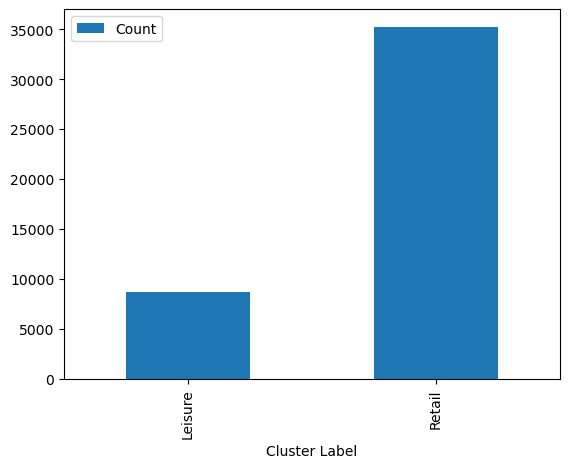

In [25]:
features_df.drop(columns=['tasmax','hurs','Binary Value']).groupby(by='Cluster Label').agg(func='count').rename(columns={"Crime ID":"Count"}).plot.bar()

In [12]:
## ratio is
counts: DataFrame = features_df.drop(columns=['tasmax','hurs']).groupby(by='Cluster Label').agg(func='count').rename(columns={"Crime ID":"Count"})

print(f"Ratio of binary target is 1:{round(number=(counts.iloc[1]/counts.iloc[0]).values[0],ndigits=2)}")



Ratio of binary target is 1:4.06


In [13]:
features_df.shape[0]/5.06

8682.608695652174

**Note** there are around 8000 samples for Leisure, this is ok.

In [14]:
features_df[["tasmax","hurs"]].corr()

,tasmax,hurs
tasmax,1.000000,-0.736143
hurs,-0.736143,1.000000


**Note** there is a relatively strong negative corellation between tasmax and relative humidity.    
**THIS MAY IMPACT THE REGRESSION**, it may be better to run a univariate method on tasmax and hurs one by one as they may compete with one another in the regression. 

In [15]:
features_df["tasmax"].describe()

count    43934.000000
mean        15.515731
std          5.700316
min          5.069943
25%         10.335984
50%         15.210895
75%         20.734396
max         27.177244
Name: tasmax, dtype: float64

<Axes: >

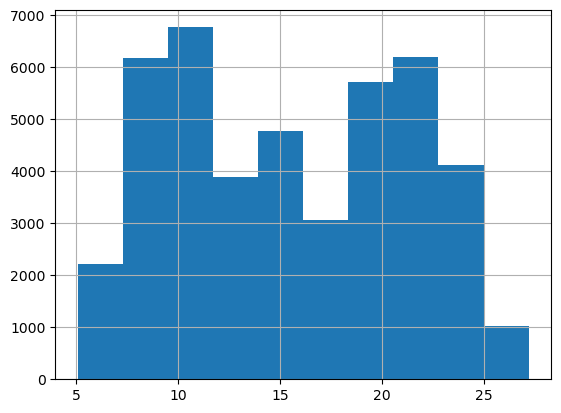

In [16]:
features_df["tasmax"].hist()

In [17]:
features_df["hurs"].describe()

count    43934.000000
mean        79.703865
std          6.608034
min         60.232498
25%         74.843475
50%         79.869659
75%         85.473717
max         93.945518
Name: hurs, dtype: float64

<Axes: >

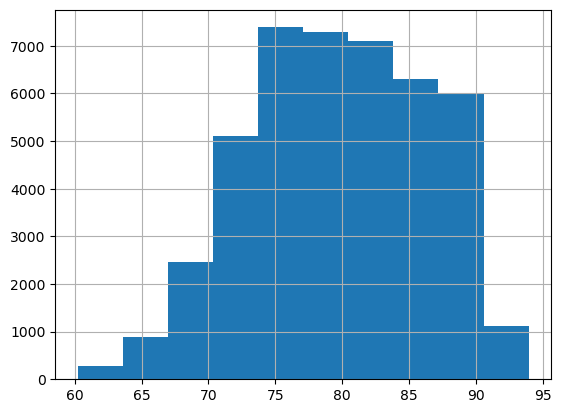

In [18]:
features_df["hurs"].hist()

In [24]:
features_df[["tasmax","hurs"]]

,tasmax,hurs
0,8.992604,89.899658
1,9.033701,88.757492
2,9.201315,88.917358
3,9.237802,89.107567
4,9.297161,89.673691
...,...,...
43929,21.899710,78.565903
43930,21.902161,79.977829
43931,21.902161,79.977829
43932,21.902161,79.977829


<Axes: xlabel='Cluster Label', ylabel='tasmax'>

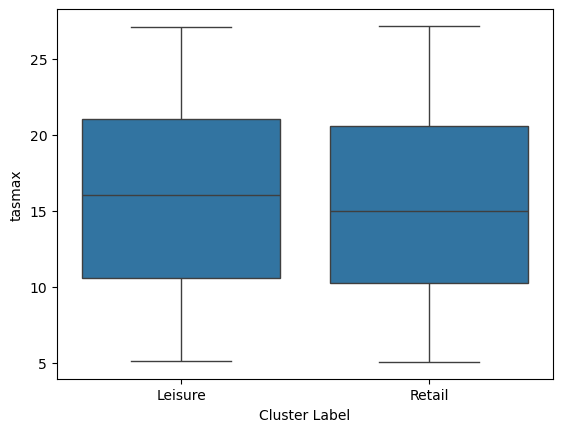

In [27]:
# look for outliers
# just one example here but see EDA topic 1
sns.boxplot(y='tasmax', x = 'Cluster Label', data=features_df)

<Axes: xlabel='Cluster Label', ylabel='hurs'>

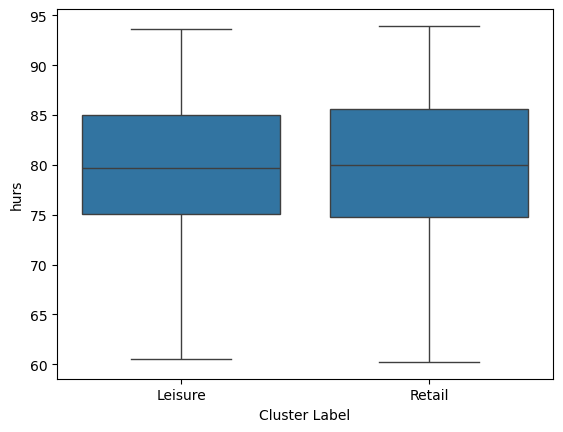

In [28]:
# look for outliers
# just one example here but see EDA topic 1
sns.boxplot(y='hurs', x = 'Cluster Label', data=features_df)

**Notes**: 

 - No extreme outliers are present so looks generally ok.   
 - Temperature has a seasonality pesent via the bimodial distrubution in the hist, but this is ok for log(odds).  
 - Obviously scales are quite different, but logistic regression can handle this so no normalisation needed. 
 - The boxplots show that hurs looks generally consistent between both Leisure and retail zones, tasmax has a higher median for Leisure zones. Roughly by eye that is. 
  


## Bivariate Logistic Regression

Initially include both weather predictors (tasmax and hurs) to test the hypothesis directly. A univariate test will be run next to check for collinearity.  

_Step 1_: Define the bivariate Logistic model with a constant included in the exogeneous dataframe

In [37]:
BV_model = sm.Logit(endog=features_df["Binary Value"],exog=sm.add_constant(data=features_df[["tasmax","hurs"]]))

_Step 2_: Fit the model

In [39]:
BV_fitted = BV_model.fit()

Optimization terminated successfully.
         Current function value: 0.496054
         Iterations 6


_Step 3_: Look at the results

In [40]:
print(BV_fitted.summary())

                           Logit Regression Results                           
Dep. Variable:           Binary Value   No. Observations:                43934
Model:                          Logit   Df Residuals:                    43931
Method:                           MLE   Df Model:                            2
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                0.002315
Time:                        16:17:59   Log-Likelihood:                -21794.
converged:                       True   LL-Null:                       -21844.
Covariance Type:            nonrobust   LLR p-value:                 1.083e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5269      0.256    -13.751      0.000      -4.030      -3.024
tasmax         0.0315      0.003     10.002      0.000       0.025       0.038
hurs           0.0205      0.003      7.524      0.0

In [47]:
def interpret_logit_results(fitted_model_in, alpha=0.05):
    # Convert from log(odds) to raw odds
    odds_ratios = np.exp(fitted_model_in.params)
    df_results = pd.DataFrame(data={"Odds Ratio": odds_ratios,
                                    "p-value": fitted_model_in.pvalues,
                                    "Stat. Significant": fitted_model_in.pvalues < alpha,})

    return df_results

In [48]:
interpret_logit_results(fitted_model_in=BV_fitted)

,Odds Ratio,p-value,Stat. Significant
const,0.029395,5.017509e-43,True
tasmax,1.032006,1.498553e-23,True
hurs,1.020699,5.308203e-14,True


_Results_

 - Constant: has a log odd of 0.02, this means that when tasmax and hurs are both set to 0 there is a high likelihood that crimes from this sample data will occur in a retail zone. The odds of 0.0294 implies that for every 1 leisure crime there is 1/0.0294=34 retail crimes if tasmax and humidity were both 0. Obviously having 0% humidity is pretty much impossible, but it does represent to imbalance of the leisure:retail ratio of the original data. 

 - Tasmax: has a log odds of 1.03, so positively impacting the odds of an event being the leisure zone. For every 1 degC increase in temperature there is a 3.2% increase in the chance of the event being is a leisure zone. 

 - Hurs: has a log odds of 1.02, so positively impacting the odds of an event being the leisure zone. For every 1% increase in humidity there is a 2% increase in the chance of the event being is a leisure zone. 

 **We can reject the null hypothesis**

## Sensitivity test on 10% subsample of data

I am aware that this is a rather huge dataset and as such the pvalues may be artifically small. To check this so a sensitivity test of Null hypothesis rejection on a subsample of 10% of the data. 10 times as this is a nice number. 

In [51]:
check: list[DataFrame] = []

In [52]:
n_runs = 10

for i in range(n_runs):
    print(f'*Running subsample check* {i}')
    features_subsample_df: DataFrame = features_df.sample(frac=0.10)
    check.append(interpret_logit_results(fitted_model_in=sm.Logit(endog=features_subsample_df["Binary Value"],exog=sm.add_constant(data=features_subsample_df[["tasmax","hurs"]])).fit()))

*Running subsample check* 0
Optimization terminated successfully.
         Current function value: 0.483545
         Iterations 6
*Running subsample check* 1
Optimization terminated successfully.
         Current function value: 0.505657
         Iterations 6
*Running subsample check* 2
Optimization terminated successfully.
         Current function value: 0.492949
         Iterations 6
*Running subsample check* 3
Optimization terminated successfully.
         Current function value: 0.482734
         Iterations 6
*Running subsample check* 4
Optimization terminated successfully.
         Current function value: 0.506342
         Iterations 5
*Running subsample check* 5
Optimization terminated successfully.
         Current function value: 0.501395
         Iterations 5
*Running subsample check* 6
Optimization terminated successfully.
         Current function value: 0.487900
         Iterations 6
*Running subsample check* 7
Optimization terminated successfully.
         Current functio

_Step 2_: Fit the model

_Step 2_: Fit the model

In [56]:
for i in range(len(check)):
    print(' ')
    print(f'{check[i]}')

 
        Odds Ratio       p-value  Stat. Significant
const     0.010658  7.129631e-08               True
tasmax    1.045187  1.914007e-05               True
hurs      1.030531  7.481229e-04               True
 
        Odds Ratio       p-value  Stat. Significant
const     0.013433  6.736506e-08               True
tasmax    1.045534  6.552488e-06               True
hurs      1.028757  8.013351e-04               True
 
        Odds Ratio   p-value  Stat. Significant
const     0.027227  0.000011               True
tasmax    1.040047  0.000097               True
hurs      1.019996  0.023076               True
 
        Odds Ratio       p-value  Stat. Significant
const     0.013132  2.080435e-07               True
tasmax    1.049181  2.759934e-06               True
hurs      1.027008  2.586542e-03               True
 
        Odds Ratio   p-value  Stat. Significant
const     0.049619  0.000171               True
tasmax    1.025570  0.011111               True
hurs      1.015852  0.062971  

This is very interesting, tasmax is consistently seen to be signficant in impacting leisure zone odds. Hurs has 2/10 subsamples where it is not significatm one is where the odds ratio is at 1.00 and the other at 1.01. tasmax varies between 1.021 and 1.049. Looks reasonable that the collinearity is impacting the results. 

## Univariate Logistic Regression - tasmax

In [65]:
def quick_UV_logit(predictor_in:str):
    print(f'Running for predictor {predictor_in}')
    print('')
    UV_model = sm.Logit(endog=features_df["Binary Value"],exog=sm.add_constant(data=features_df[[predictor_in]])).fit()
    print('')
    print('Summary:')
    print(UV_model.summary())
    print('')
    print('==============================================================================')
    print('**Quick Interpretation:**')
    print('==============================================================================')
    print(interpret_logit_results(fitted_model_in=UV_model, alpha=0.05))
    print('==============================================================================')

In [66]:
quick_UV_logit(predictor_in='tasmax')

Running for predictor tasmax

Optimization terminated successfully.
         Current function value: 0.496705
         Iterations 5

Summary:
                           Logit Regression Results                           
Dep. Variable:           Binary Value   No. Observations:                43934
Model:                          Logit   Df Residuals:                    43932
Method:                           MLE   Df Model:                            1
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                0.001006
Time:                        17:04:09   Log-Likelihood:                -21822.
converged:                       True   LL-Null:                       -21844.
Covariance Type:            nonrobust   LLR p-value:                 3.389e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6187      0.035    -45.878      0.000      -1.688  

## Univariate Logistic Regression - hurs

In [67]:
quick_UV_logit(predictor_in='hurs')

Running for predictor hurs

Optimization terminated successfully.
         Current function value: 0.497205
         Iterations 5

Summary:
                           Logit Regression Results                           
Dep. Variable:           Binary Value   No. Observations:                43934
Model:                          Logit   Df Residuals:                    43932
Method:                           MLE   Df Model:                            1
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:               9.124e-07
Time:                        17:05:49   Log-Likelihood:                -21844.
converged:                       True   LL-Null:                       -21844.
Covariance Type:            nonrobust   LLR p-value:                    0.8418
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4295      0.145     -9.857      0.000      -1.714    

## Conclusions

- Overall  result is to reject the null hypothesis in favor of the alternative hypothis that "Increases in maximum ambient air temperature and humidity significantly increase the odds of a crime occuring in a Leisure cluster versus a retail cluster."

- The multivariate logistic regression shows that 1degC increase in temp raises leisure crime odds by 3.2% and +1% increase in humidity raises odds by 2.1% when considered together. Temperature is more robust, with humidity being more sensisitive to sample selection by still generally robust. 

- There appears to be a `Suppressor Effect' going on here. When looking at humidity alone the predictor is insignificant, when looking at max temp alone the odds increase still significant but at 1% it is notably smaller. This shows that despite the risk of collinearity you need to include both temperaure and humidity as predictors as they impact odds as a combination. This links to the fact that temperature and humifity combine to form the wet bulb temperature and THIS is what impacts human comfort -> warm and humid = difficulty to cool and impacts on behaviour. 

**Overall: Combined temp/humidity reflects Wet-Bulb heat stress, a driver for outdoor leisure zone crime events.**


## Extras 1 - exhasutive BV

In [77]:
feature_exhaustive_query = """SELECT "Crime ID",
                          "Cluster Label",
                          "tasmax",                                        --Independent variable 1
                          "hurs",                                           --Independent varibale 2
                          "groundfrost",
                          "sun",
                          "snowLying",
                          "tasmin",
                          "tas",
                          "rainfall",
                          "sfcwind"
                          FROM crimetology_NS_clean 
                          WHERE "Cluster Label" IN ('Leisure','Retail');   --Dependent variable
                """


In [78]:
features_exhasutive_df: DataFrame = con.execute(query=feature_exhaustive_query).df()
features_exhasutive_df

,Crime ID,Cluster Label,tasmax,hurs,groundfrost,sun,snowLying,tasmin,tas,rainfall,sfcWind
0,42a431be7080b174dc6a6fe419678ae1c6e2a81afc82d6...,Leisure,8.992604,89.899658,9.822821,61.205822,0.182533,3.622673,6.298035,54.864017,4.399464
1,f92c6b203564a084e8ec1ae523433302ca903f9783c89f...,Retail,9.033701,88.757492,10.053925,69.866371,0.045262,3.584216,6.224151,61.193233,4.896767
2,728733ef4da4abf89f8a83b3f1104d1142683febcfefc7...,Leisure,9.201315,88.917358,8.425074,62.469185,0.041273,3.607168,6.366257,63.139992,5.196404
3,f183e986bb0043037d40b5848c7d66bacd570eecf7a9c4...,Retail,9.237802,89.107567,8.096927,60.260311,0.116909,4.029425,6.624474,52.358356,4.471696
4,08059176f2ca15ed52158c38966df742603f12105e5942...,Retail,9.297161,89.673691,11.236046,55.952740,0.061154,3.368905,6.224165,45.252079,4.178386
...,...,...,...,...,...,...,...,...,...,...,...
43929,72c74647c90095c29306baba145140affcb7aaa00ca953...,Leisure,21.899710,78.565903,0.000000,145.203934,0.000000,12.814150,17.368160,58.801945,3.380369
43930,b01fe8dc3c05f6436741f4e67f68cb19426db26763ae01...,Retail,21.902161,79.977829,0.000000,142.707520,0.000000,12.457700,17.200424,60.758396,3.416855
43931,7d4a1dca0d15ac78d98770d23d604c0391df74e2f2e2a2...,Retail,21.902161,79.977829,0.000000,142.707520,0.000000,12.457700,17.200424,60.758396,3.416855
43932,efe28a09d0b076e396b4e775ca9ccf78b0ee73c3095d64...,Retail,21.902161,79.977829,0.000000,142.707520,0.000000,12.457700,17.200424,60.758396,3.416855


In [79]:
features_exhasutive_df["Binary Value"] = (features_exhasutive_df["Cluster Label"]=='Leisure').astype(int)

In [81]:
BV_exhaustive_model = sm.Logit(endog=features_exhasutive_df["Binary Value"],exog=sm.add_constant(data=features_exhasutive_df[["tasmax","hurs","groundfrost","sun","snowLying","tasmin","tas","rainfall","sfcWind"]]))

_Step 2_: Fit the model

In [82]:
BV_exhaustive_fitted = BV_exhaustive_model.fit()

Optimization terminated successfully.
         Current function value: 0.482887
         Iterations 6


_Step 3_: Look at the results

In [83]:
print(BV_exhaustive_fitted.summary())

                           Logit Regression Results                           
Dep. Variable:           Binary Value   No. Observations:                43934
Model:                          Logit   Df Residuals:                    43924
Method:                           MLE   Df Model:                            9
Date:                Fri, 14 Aug 2026   Pseudo R-squ.:                 0.02880
Time:                        17:39:41   Log-Likelihood:                -21215.
converged:                       True   LL-Null:                       -21844.
Covariance Type:            nonrobust   LLR p-value:                3.420e-265
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -17.9979      0.543    -33.134      0.000     -19.063     -16.933
tasmax          0.6973      0.093      7.480      0.000       0.515       0.880
hurs            0.1461      0.005     29.698    

In [87]:
interpret_logit_results(fitted_model_in=BV_exhaustive_fitted).sort_values(by='Odds Ratio',ascending=False).round(6)

,Odds Ratio,p-value,Stat. Significant
tasmax,2.008303,0.000000,True
sfcWind,1.484799,0.000000,True
tasmin,1.204452,0.044197,True
snowLying,1.160504,0.000000,True
hurs,1.157261,0.000000,True
sun,1.008024,0.000000,True
rainfall,0.995433,0.000000,True
groundfrost,0.995183,0.341882,False
tas,0.419226,0.000002,True
const,0.000000,0.000000,True


wind speed is suprisingly highly ranked here towards increasing the odds of leisure crime. sunshine hours are neutral, as expected. But this is probably not to be trusted as there is no EDA, collinearity checks etc. I dont have time to do this right now. 